```
차원의 저주(Curse of Dimensionality)는 데이터의 변수(차원)가 늘어날 때 발생할 수 있는 데이터 분석과 머신러닝의 가장 고질적인 문제.

1. 직관적인 예시: 벼룩 잡기 게임 (희소성 비유)
데이터의 차원이 증가하면서 생기는 희소성(Sparsity)과 거리의 멀어짐을 공간으로 비유.
•	1차원 (선 위에서 벼룩 잡기): 길이가 10cm인 실 위에 벼룩 10마리가 있습니다. 대충 1cm 간격으로 조밀하게 모여 있어 손가락으로 꾹 누르면 쉽게 잡을 수 있습니다. (데이터 밀도가 높음)
•	2차원 (면 위에서 벼룩 잡기): 가로 10cm, 세로 10cm인 도화지(10 X 10 = 100개의 칸) 위에 똑같이 벼룩 10마리를 흩어놓습니다. 이제 벼룩 간의 거리가 멀어지고 빈 공간이 훨씬 많아집니다
•	3차원 (상자 속에서 벼룩 잡기): 가로, 세로, 높이가 각각 10cm인 투명 상자(10 X 10 X 10 = 1,000개의 칸) 안에 벼룩 10마리를 넣습니다. 상자의 99%는 텅 빈 공간이 되고 벼룩들은 서로 마주치기조차 힘든 먼 거리에 위치하게 됩니다.
결론: 차원(변수)이 늘어날수록 공간의 부피는 기하급수적으로 커지지만, 우리가 가진 데이터(벼룩)의 개수가 그대로라면 데이터는 공간 전체에 매우 듬성듬성하게 존재하게 됩니다. 이것이 데이터 희소성(Sparsity)이며, 거리가 너무 멀어져 서로 어떤 관계인지 분석하기가 불가능해집니다.
```

In [1]:
# 2. 파이썬 실습: 차원 증가에 따른 무작위 샘플 간의 거리 변화
# 실제로 차원이 커질 때 데이터 포인트 간의 거리가 얼마나 멀어지는지 계산해 보는 파이썬 예제 코드. 변수가 많아질수록 샘플들이 서로 '우주 미아'처럼 멀어지는 것을 눈으로 확인할 수 있다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# 실습을 위해 동일한 샘플 수(100개)를 유지
n_samples = 100
dimensions = [2, 10, 100, 1000] # 2차원부터 1000차원까지 비교

results = {}

for dim in dimensions:
    # 0과 1 사이의 무작위 값을 가진 dim차원의 데이터 100개 생성
    np.random.seed(42)
    X = np.random.rand(n_samples, dim)
    
    # 모든 샘플 쌍 간의 유클리드 거리를 계산 (pdist)
    distances = pdist(X, metric='euclidean')
    
    # 평균 거리와 최소/최대 거리를 저장
    results[f'{dim}차원'] = {
        '평균 거리': np.mean(distances),
        '최소 거리': np.min(distances),
        '최대 거리': np.max(distances)
    }

# 결과 출력
df_res = pd.DataFrame(results).T
print("--- 차원별 데이터 간의 거리 변화 ---")
print(df_res)

--- 차원별 데이터 간의 거리 변화 ---
            평균 거리      최소 거리      최대 거리
2차원      0.534641   0.002673   1.237818
10차원     1.280340   0.462859   2.128879
100차원    4.063738   3.209023   5.063175
1000차원  12.890145  11.966975  13.715660


원래 데이터의 모양 (4차원): (150, 4)
PCA 적용 후 데이터의 모양 (2차원): (150, 2)


C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\DEV\dp_31

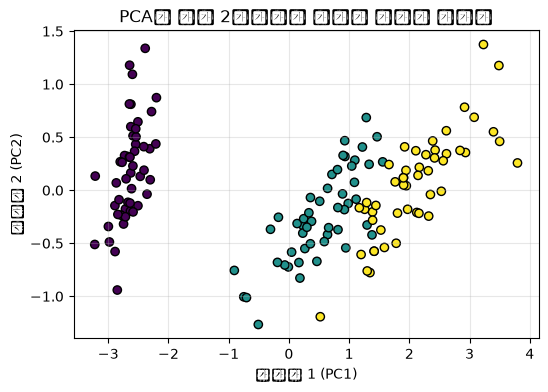

In [3]:
# 3. PCA(주성분분석)를 이용한 해결
# 수백 개의 변수 때문에 모델이 꼬이고 오버피팅(과적합)이 발생할 때 PCA(Principal Component Analysis)를 사용하면 정보 손실을 최소화하면서 차원을 싹 줄일 수 있다.

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# 1. 꽃받침 길이, 너비 등 4개의 변수(4차원)를 가진 붓꽃 데이터 로드
iris = load_iris()
X_iris = iris.data
print(f"원래 데이터의 모양 (4차원): {X_iris.shape}")

# 2. PCA를 사용하여 정보가 가장 잘 집약된 2개의 주성분(2차원)으로 압축
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_iris)

print(f"PCA 적용 후 데이터의 모양 (2차원): {X_pca.shape}")

# 3. 2차원으로 줄였기 때문에 이제 2D 평면에 시각화(Scatter plot)가 가능해집니다!
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris.target, cmap='viridis', edgecolors='k')
plt.title('PCA를 통해 2차원으로 축소된 데이터 시각화')
plt.xlabel('주성분 1 (PC1)')
plt.ylabel('주성분 2 (PC2)')
plt.grid(True, alpha=0.3)
plt.show()